# **Carga de librerías**

In [1]:
# Instalación de las librerías
%pip install torch torchvision scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn # Modulo para redes neuronales
import torch.optim as optim # Modulo para optimizadores

# Modulo para cargar y transformar datos
import torchvision
from torchvision import datasets, transforms, models

# Modulo para visualización
import matplotlib.pyplot as plt
import numpy as np

# Modulo para evaluación de modelos
from sklearn.metrics import classification_report, confusion_matrix

import os

# **Carga del dataset**

In [3]:
raiz = '../data/Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


# **Data Augmentation**

Se va a aplicar un data augmentation equivalente al de keras, teniendo en cuenta que en pytorch este se hace con *transforms* de la siguiente manera:

In [4]:
# Data augmentation para el conjunto de entrenamiento
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Volteo horizontal aleatorio
    transforms.RandomVerticalFlip(), # Volteo vertical aleatorio
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(1.0, 1.0)), # Zoom aleatorio
    transforms.RandomRotation(20), # Rotación aleatoria
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para el conjunto de validacion
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para el conjunto de prueba
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

Ahora cargamos los tres conjuntos y le asignamos un batch size con el módulo de torch

In [6]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16,
                                           shuffle=True)

val_loader = torch.utils.data.DataLoader(val_dataset,
                                         batch_size=16,
                                         shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=1,
                                          shuffle=False)

# **Carga de la red VGG19**

Ahora ya teniendo los datos cargados y procesados, vamos a cargar la red VGG19 con el módulo *models* de **torchvision**.

In [7]:
base_model = models.vgg19(pretrained=True)

# Visualizo todo el modelo para entender su estructura
print(base_model)

/home/franco/Redes-Neuronales-en-Keras/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/franco/Redes-Neuronales-en-Keras/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

# **Aplicar la técnica de fine-tuning**

Para aplicar esta técnica debo congelar las capas convolucionales del propio modelo, y modifico la capa densa final para que se adapte a mi problema.

In [8]:
base_model.classifier[6] = nn.Linear(4096, 2)

for param in base_model.features.parameters():
    param.requires_grad = False

for param in base_model.classifier.parameters(): # Solo entreno la parte del clasificador
    param.requires_grad = True

In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
base_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

## **Establecer la función de pérdida (loss) y el optimizador**

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
  base_model.parameters(),
  lr=1e-4
)

# **Entrenamiento del modelo**

In [19]:
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
	train_loss, val_loss = [], []
	train_acc, val_acc = [], []
	best_val_loss = float("inf")

	for epoch in range(num_epochs):
		model.train()
		running_loss = 0.0
		running_correct = 0
		total = 0

		for images, labels in train_loader:
			images = images.to(device)
			labels = labels.to(device)

			optimizer.zero_grad()  # evitar problemas con el gradiente para entrenar
			outputs = model(images)

			loss = criterion(outputs, labels)
			loss.backward()
			optimizer.step()

			running_loss += loss.item()
			_, preds = torch.max(outputs, 1)
			running_correct += torch.sum(preds == labels).item()
			total += images.size(0)

		epoch_loss = running_loss / len(train_loader)
		epoch_acc = running_correct / max(1, total)
		train_loss.append(epoch_loss)
		train_acc.append(epoch_acc)

		model.eval()
		loss_val = 0.0
		running_val_correct = 0
		total_val = 0

		with torch.no_grad():
			for images, labels in val_loader:
				images = images.to(device)
				labels = labels.to(device)

				outputs = model(images)
				loss = criterion(outputs, labels)

				loss_val += loss.item()
				_, preds = torch.max(outputs, 1)
				running_val_correct += torch.sum(preds == labels).item()
				total_val += images.size(0)

		epoch_val_loss = loss_val / len(val_loader)
		epoch_val_acc = running_val_correct / max(1, total_val)
		val_loss.append(epoch_val_loss)
		val_acc.append(epoch_val_acc)

		print(
			f"Epoch {epoch + 1}/{num_epochs}: "
			f"Train_acc: {epoch_acc:.4f}, Train_loss: {epoch_loss:.4f}, "
			f"Val_acc: {epoch_val_acc:.4f}, Val_loss: {epoch_val_loss:.4f}"
		)

		# --- Guardar el mejor modelo ---
		if epoch_val_loss < best_val_loss:
			best_val_loss = epoch_val_loss
			torch.save(
				{
					"epoch": epoch,
					"model_state_dict": model.state_dict(),
					"optimizer_state_dict": optimizer.state_dict(),
					"val_loss": epoch_val_loss,
					"val_acc": epoch_val_acc,
					"train_loss": epoch_loss,
					"train_acc": epoch_acc,
				},
				"best_vgg19_model.pth",
			)
			print(f"Modelo guardado con pérdida de validación: {best_val_loss:.4f}")

	return train_acc, train_loss, val_acc, val_loss

In [20]:
train_acc, train_loss, val_acc, val_loss = train(base_model, train_loader, val_loader, criterion, optimizer, device, num_epochs=100)

Epoch 1/100: Train_acc: 0.8112, Train_loss: 0.4763, Val_acc: 0.7917, Val_loss: 0.6058
Modelo guardado con pérdida de validación: 0.6058
Epoch 2/100: Train_acc: 0.7640, Train_loss: 0.5381, Val_acc: 0.7500, Val_loss: 0.6177
Epoch 3/100: Train_acc: 0.8555, Train_loss: 0.3670, Val_acc: 0.7917, Val_loss: 0.6071
Epoch 4/100: Train_acc: 0.8230, Train_loss: 0.4862, Val_acc: 0.7917, Val_loss: 0.6299
Epoch 5/100: Train_acc: 0.8024, Train_loss: 0.4654, Val_acc: 0.6875, Val_loss: 1.0298
Epoch 6/100: Train_acc: 0.8584, Train_loss: 0.2835, Val_acc: 0.7708, Val_loss: 0.5602
Modelo guardado con pérdida de validación: 0.5602
Epoch 7/100: Train_acc: 0.8260, Train_loss: 0.4343, Val_acc: 0.7917, Val_loss: 0.5556
Modelo guardado con pérdida de validación: 0.5556
Epoch 8/100: Train_acc: 0.8437, Train_loss: 0.3501, Val_acc: 0.7917, Val_loss: 0.6084
Epoch 9/100: Train_acc: 0.8820, Train_loss: 0.2897, Val_acc: 0.6875, Val_loss: 0.8319
Epoch 10/100: Train_acc: 0.9027, Train_loss: 0.2387, Val_acc: 0.7917, Val_lo

# **Evaluación del modelo**

Para ello crearé una función para realizar la evaluación del modelo

In [21]:
def evaluate(model, test_loader, device):
	model.eval()

	correct, total = 0, 0

	with torch.no_grad():
		for images, labels in test_loader:
			images = images.to(device)
			labels = labels.to(device)

			outputs = model(images)
			_, predicted = torch.max(outputs.data, 1)

			total += labels.size(0)
			correct += (predicted == labels).sum().item()
			
	accuracy = 100 * correct / total
	print(f"Test Accuracy: {accuracy:.2f}%")
	print(f"Test Error: {100 - accuracy:.2f}%")

In [24]:
# Cargo el mejor modelo guardado
checkpoint = torch.load("best_vgg19_model.pth")
base_model.load_state_dict(checkpoint["model_state_dict"])

evaluate(base_model, test_loader, device)

Test Accuracy: 88.78%
Test Error: 11.22%


# **Visualización de las curvas de entrenamiento**

Esta es la visualización de las curvas del mejor modelo una vez realizado el *fine-tuning*.

In [29]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc, best_epoch=None, model_name='Modelo'):
    """
    Visualiza las curvas de entrenamiento y validación.
    
    Args:
        train_loss  : lista con la pérdida de entrenamiento por época
        val_loss    : lista con la pérdida de validación por época
        train_acc   : lista con la precisión de entrenamiento por época
        val_acc     : lista con la precisión de validación por época
        best_epoch  : (opcional) época del mejor modelo para marcarlo en la gráfica
        model_name  : (opcional) nombre del modelo para el título
    """
    plt.figure(figsize=(12, 5))

    # --- Curva de Pérdida ---
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    if best_epoch is not None:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Mejor modelo (época {best_epoch+1})')
        plt.scatter([best_epoch], [val_loss[best_epoch]], color='red', zorder=5)
    plt.title(f'Curva de Pérdida - {model_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    # --- Curva de Precisión ---
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    if best_epoch is not None:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Mejor modelo (época {best_epoch+1})')
        plt.scatter([best_epoch], [val_acc[best_epoch]], color='red', zorder=5)
    plt.title(f'Curva de Precisión - {model_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

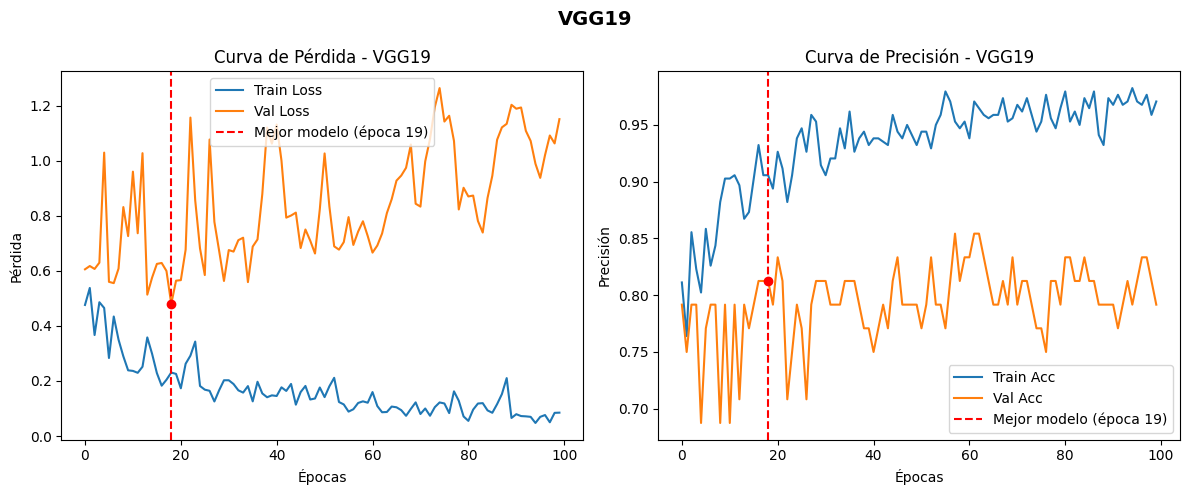

In [31]:
plot_training_curves(train_loss, val_loss, train_acc, val_acc, best_epoch=np.argmin(val_loss), model_name='VGG19')

# **Deep Learning**

Ahora aplico el *deep learning* teniendo en cuenta el mejor modelo entrenado anteriormente con el *fine tuning*.

In [32]:
# Cargo el mejor modelo guardado
checkpoint = torch.load("best_vgg19_model.pth")
base_model.load_state_dict(checkpoint["model_state_dict"])

# Activo todas las capas
for param in base_model.features.parameters():
    param.requires_grad = True

for param in base_model.classifier.parameters():
    param.requires_grad = True
    
# Realizo el nuevo entrenamiento
train_acc, train_loss, val_acc, val_loss = train(base_model, train_loader, val_loader, criterion, optimizer, device, num_epochs=100)

Epoch 1/100: Train_acc: 0.7522, Train_loss: 0.7054, Val_acc: 0.6458, Val_loss: 0.6308
Modelo guardado con pérdida de validación: 0.6308
Epoch 2/100: Train_acc: 0.8260, Train_loss: 0.3832, Val_acc: 0.7708, Val_loss: 0.5176
Modelo guardado con pérdida de validación: 0.5176
Epoch 3/100: Train_acc: 0.8850, Train_loss: 0.2588, Val_acc: 0.8958, Val_loss: 0.2247
Modelo guardado con pérdida de validación: 0.2247
Epoch 4/100: Train_acc: 0.9027, Train_loss: 0.2905, Val_acc: 0.6875, Val_loss: 1.7639
Epoch 5/100: Train_acc: 0.7965, Train_loss: 0.4568, Val_acc: 0.6458, Val_loss: 0.6945
Epoch 6/100: Train_acc: 0.8732, Train_loss: 0.2768, Val_acc: 0.8333, Val_loss: 0.6448
Epoch 7/100: Train_acc: 0.9145, Train_loss: 0.2439, Val_acc: 0.8125, Val_loss: 0.5117
Epoch 8/100: Train_acc: 0.9263, Train_loss: 0.2059, Val_acc: 0.7708, Val_loss: 0.6815
Epoch 9/100: Train_acc: 0.8968, Train_loss: 0.2474, Val_acc: 0.8333, Val_loss: 0.4975
Epoch 10/100: Train_acc: 0.9056, Train_loss: 0.2070, Val_acc: 0.7500, Val_lo

In [33]:
# Evaluación del modelo teniendo en cuenta el mejor modelo guardado
checkpoint = torch.load("best_vgg19_model.pth")
base_model.load_state_dict(checkpoint["model_state_dict"])

evaluate(base_model, test_loader, device)

Test Accuracy: 86.73%
Test Error: 13.27%


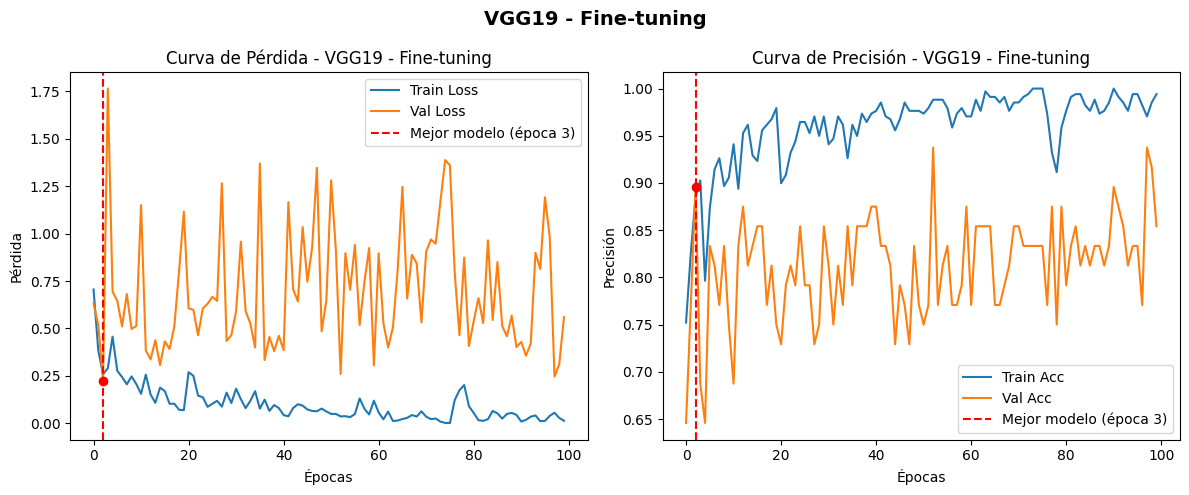

In [34]:
# Visualización de las métricas de entrenamiento
plot_training_curves(train_loss, val_loss, train_acc, val_acc, best_epoch=np.argmin(val_loss), model_name='VGG19 - Fine-tuning')